# Import

- increase the threshold on pseudobulking cell count 
- find TFs highly correlated with ageing

In [2]:
cell_types = ['CD4T', 'CD8T', 'NK', 'B', 'MONO']

par = {
    # - global vars
    'cell_type': cell_types[3],
    'datasets': ['data1', 'data7_allTPs_jalil'], # data7_allTPs_jalil
    'top_n_central_tf': 50,
    'top_n_predictor_tf': 50,
}
par['report'] = f"{par['cell_type']}.yaml"

data1 = par['datasets'][0]
data2 = par['datasets'][1]

In [3]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import sys 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
task_grn_inference_dir = '../../'
helper_dir = '../src/tf_activity/'
output_dir = '../output'

# - local imports
sys.path.append(task_grn_inference_dir)
sys.path.append(helper_dir)


# - global vars
cell_type = par['cell_type']
datasets = par['datasets']

# - color palette
color_palette = sns.color_palette("tab10", len(datasets))  
datasets_colors = {label: color for label, color in zip(datasets, color_palette)}

# - lambda functions
net_lambda = lambda dataset, cell_type:  pd.read_csv(f'{output_dir}/grns/{dataset}/net_{cell_type}_all_agegroups_all_batches.csv')
adata_lambda = lambda dataset: ad.read_h5ad(f"/vol/projects/jnourisa/datasets/{dataset}_bulk.h5ad") 

# - file imports and subsets
tf_all = np.loadtxt(f'{task_grn_inference_dir}/task_grn_inference/resources/grn_benchmark/prior/tf_all.csv', dtype=str)
nets_dict = {dataset: net_lambda(dataset, cell_type) for dataset in datasets}
nets_dict = {dataset: net.loc[net['source'].isin(tf_all)] for dataset, net in nets_dict.items()}
adata_complete_dict = {dataset: adata_lambda(dataset) for dataset in datasets}
adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete_dict.items()}


## UMAP of pseudo bulked expression 

In [4]:
def plot_embeding(dataset):
    adata = adata_complete_dict[dataset]
    sc.pp.neighbors(adata, n_neighbors=10)
    sc.tl.umap(adata)

    size_values = 3*(adata.obs['cell_count'] / adata.obs['cell_count'].max() * 100)  
    sc.pl.umap(adata, color=['cell_type', 'sex'], wspace=0.3, size=size_values, title=dataset)
    sc.pl.pca(adata, color=['cell_type', 'sex'], wspace=0.3, size=size_values, title=dataset)

In [5]:
if False:
    plot_embeding(data1)

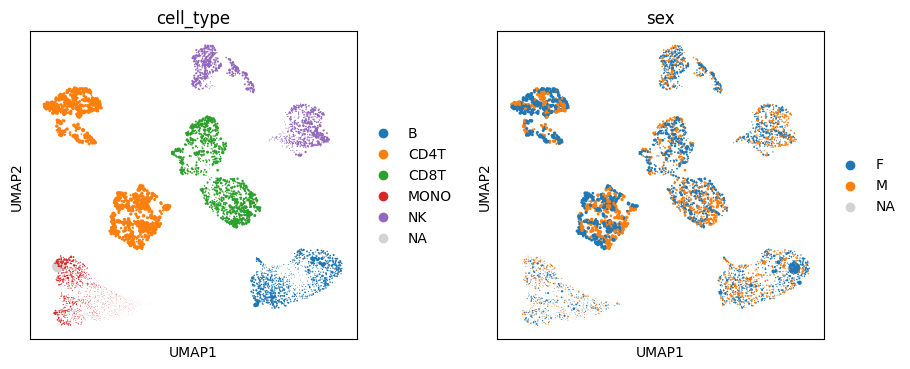

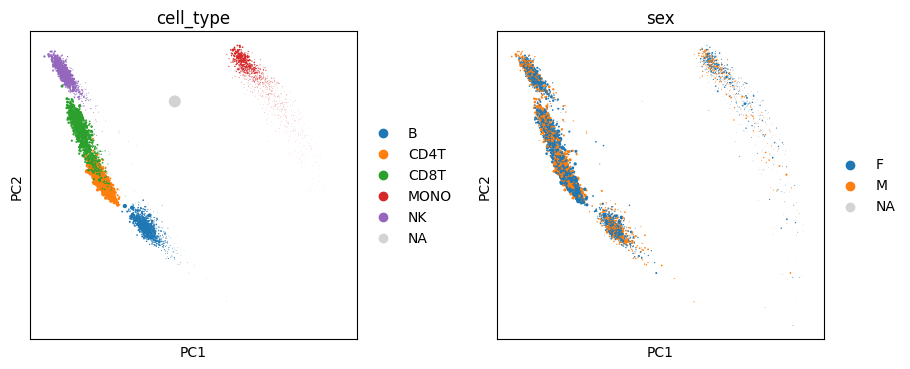

In [6]:
if False:
    plot_embeding(data2)

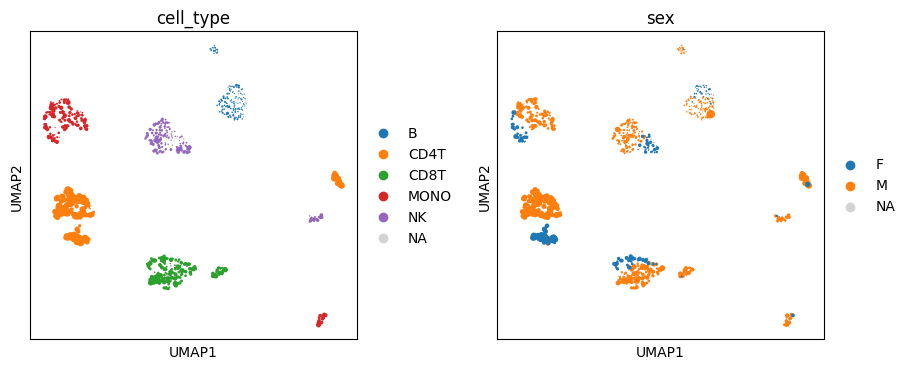

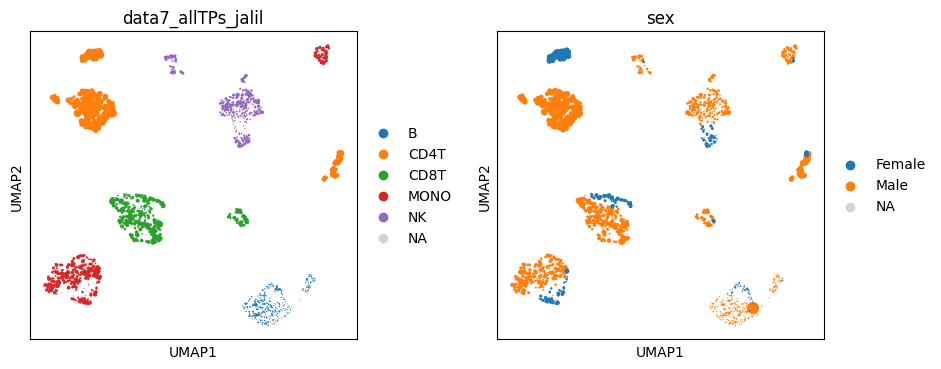

## Cell count: pseudobulking

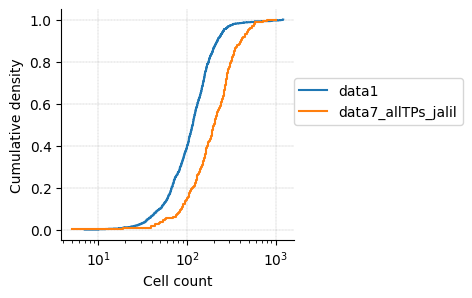

In [7]:
from task_grn_inference.src.exp_analysis.helper import plot_cumulative_density
fig, ax = plt.subplots(1, 1, figsize=(3, 3), sharey=True)
for i, dataset in enumerate(datasets):
    adata = adata_dict[dataset]
    cell_count = adata.obs['cell_count']
    plot_cumulative_density(cell_count, ax=ax, label=dataset)
    ax.set_xlabel('Cell count')
    ax.set_ylabel('Cumulative density')
    ax.set_xscale('log')
plt.legend(loc=(1, .5))
    

## TF activation calculate


In [ ]:
# - tf activity for all datasets
sys.path.append('../')
from src.tf_activity.helper import enrich_tfs
def convert_long_table_2_adata(tf_acts):
    # - convert long table to adata 
    index_col = ["age", "donor_id", "cell_count"]
    tf_acts_table = tf_acts.pivot(index=index_col, columns='source', values='activity').fillna(0)
    tf_acts_table = tf_acts_table.reset_index()  


    tf_acts_adata = ad.AnnData(obs=tf_acts_table[index_col], X=tf_acts_table[[col for col in tf_acts_table.columns if col not in index_col]])
    # tf_acts_adata.obs.index = tf_acts_adata.obs.index.astype(int)
    tf_acts_adata.obs['age'] = pd.to_numeric(tf_acts_adata.obs['age'], errors='coerce')

    return tf_acts_adata

tf_acts_dict = {}
tf_acts_adata_dict = {}
for dataset in datasets:

    tf_acts = enrich_tfs(adata_dict[dataset], nets_dict[dataset])
    if 'index' in tf_acts.columns:
        tf_acts = tf_acts.drop('index', axis=1)
    tf_acts_dict[dataset] = tf_acts
    tf_acts_adata_dict[dataset] = convert_long_table_2_adata(tf_acts)

## Centrality profile 

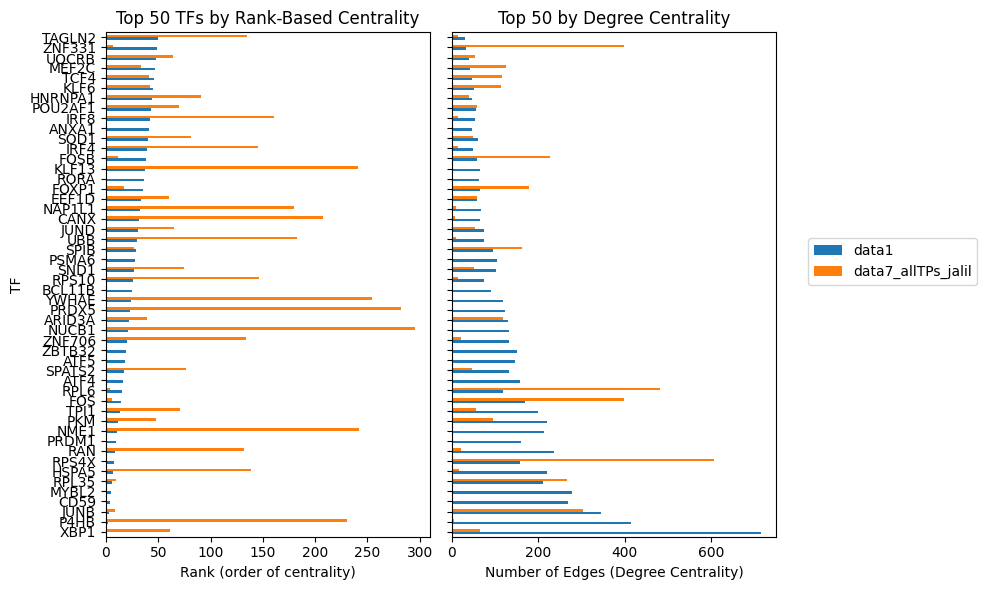

<Figure size 400x400 with 0 Axes>

In [8]:
# Compute centrality metrics
centrality1 = nets_dict[data1].groupby('source')['weight'].apply(lambda x: x.abs().sum())
centrality2 = nets_dict[data2].groupby('source')['weight'].apply(lambda x: x.abs().sum())

# Compute ranks (lower rank = more central), then reverse
rank1 = centrality1.rank(method='min', ascending=False)
rank2 = centrality2.rank(method='min', ascending=False)

# Compute degree centrality (Number of edges)
degree1 = nets_dict[data1].groupby('source').size()
degree2 = nets_dict[data2].groupby('source').size()

# Get the top n tfs
top_genes_1 = centrality1.sort_values(ascending=False).head(par['top_n_central_tf']).index
top_genes_2 = centrality2.sort_values(ascending=False).head(par['top_n_central_tf']).index

# Prepare data for plotting
df_rank = pd.DataFrame({
    data1: rank1.reindex(top_genes_1, fill_value=0).values,
    data2: rank2.reindex(top_genes_1, fill_value=0).values
}, index=top_genes_1)

df_degree = pd.DataFrame({
    data1: degree1.reindex(top_genes_1, fill_value=0).values,
    data2: degree2.reindex(top_genes_1, fill_value=0).values
}, index=top_genes_1)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)

# Rank-based centrality
df_rank.plot(kind='barh', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_xlabel("Rank (order of centrality)")
axes[0].set_ylabel("TF")
axes[0].set_title(f"Top {par['top_n_central_tf']} TFs by Rank-Based Centrality")
axes[0].invert_yaxis()
axes[0].get_legend().remove()

# Degree-based centrality
df_degree.plot(kind='barh', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_xlabel("Number of Edges (Degree Centrality)")
axes[1].set_title(f"Top {par['top_n_central_tf']} by Degree Centrality")
axes[1].legend(loc=(1.1, .5))

plt.tight_layout()
plt.show()
# Adjust layout
plt.tight_layout()

In [9]:
centrality_merged = centrality1[:par['top_n_central_tf']].reset_index(name='degree').merge(centrality2[:par['top_n_central_tf']].reset_index(name='degree'), on='source', suffixes=('_1', '_2'), how='outer').fillna(0)
print('spearman corr among top central tfs: ', spearmanr(centrality_merged['degree_1'], centrality_merged['degree_2']))

spearman corr among top central tfs:  SignificanceResult(statistic=-0.28275967803756225, pvalue=0.014645914464516617)


Jaccard Similarity: 0.163
Common top TFs: ['RPL35', 'FOS', 'KLF6', 'RPL6', 'MEF2C', 'FOSB', 'FOXP1', 'ZNF331', 'JUNB', 'TCF4', 'ARID3A', 'PKM', 'RPS4X', 'SPIB']
Spearman Correlation: 0.349, p-value: 0.221


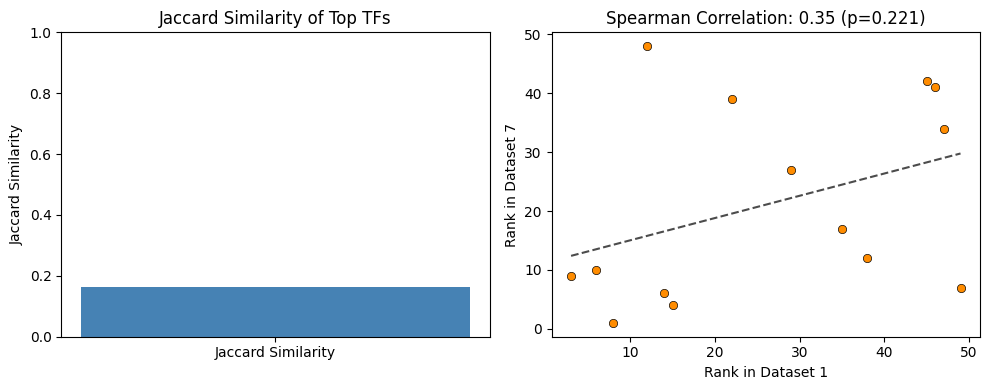

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import spearmanr

# Get the top n central TFs for each dataset
top_tfs_1 = set(centrality1.nlargest(par['top_n_central_tf']).index)
top_tfs_7 = set(centrality2.nlargest(par['top_n_central_tf']).index)

# Compute Jaccard similarity
jaccard_similarity = len(top_tfs_1 & top_tfs_7) / len(top_tfs_1 | top_tfs_7)
print(f"Jaccard Similarity: {jaccard_similarity:.3f}")

# Create a figure
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar plot for Jaccard similarity
axes[0].bar(["Jaccard Similarity"], [jaccard_similarity], color="steelblue")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Jaccard Similarity")
axes[0].set_title("Jaccard Similarity of Top TFs")

# Get intersection of top TFs in both datasets
common_top_tfs = list(top_tfs_1 & top_tfs_7)
print('Common top TFs:', common_top_tfs)

if common_top_tfs:
    # Extract ranks for common TFs
    rank1_common = rank1.loc[common_top_tfs]
    rank2_common = rank2.loc[common_top_tfs]

    # Compute Spearman correlation
    spearman_corr, p_value = spearmanr(rank1_common, rank2_common)
    print(f"Spearman Correlation: {spearman_corr:.3f}, p-value: {p_value:.3f}")

    # Scatter plot for Spearman correlation
    sns.scatterplot(x=rank1_common, y=rank2_common, ax=axes[1], color="darkorange", edgecolor="black")
    
    # Fit a trend line
    slope, intercept = np.polyfit(rank1_common, rank2_common, 1)
    x_vals = np.linspace(rank1_common.min(), rank1_common.max(), 100)
    axes[1].plot(x_vals, slope * x_vals + intercept, color="black", linestyle="--", alpha=0.7)

    # Labels
    axes[1].set_xlabel("Rank in Dataset 1")
    axes[1].set_ylabel("Rank in Dataset 7")
    axes[1].set_title(f"Spearman Correlation: {spearman_corr:.2f} (p={p_value:.3g})")
else:
    print("No common TFs in the top list for both datasets.")

plt.tight_layout()
plt.show()

ratio of porosity:  0.9661349693251534
net: (200, 1141), mat: (1141, 981), source: 200
ratio of porosity:  0.9717150909440754
net: (318, 1667), mat: (1667, 313), source: 318


In [12]:
# adata = tf_acts_adata_dict[data1]
# adata[adata.obs['age'] == 28]

## TF activation trajectory based on top central TFs

In [16]:
# - find sig tfs for each dataset and then choose common ones
from helper import determin_stats, summary_stats
stats_store = []
for dataset in datasets:
    stats = determin_stats(tf_acts_adata_dict[dataset], common_top_tfs)
    stats['dataset'] = dataset
    stats_store.append(stats)
stats_central_tfs = pd.concat(stats_store)


In [ ]:
summary_stats_central_tfs = summary_stats(stats_central_tfs)
summary_stats_central_tfs.head(10)

## Top TF predictors of age

In [163]:
from helper import find_robust_predictors

covariates = ["age", "donor_id"]
target = 'age'

top_predictors_data1 = find_robust_predictors(
    tf_acts_adata_dict[data1], covariates, target, top_k=par['top_n_predictor_tf']
)
top_predictors_data7 = find_robust_predictors(
    tf_acts_adata_dict[data2], covariates, target, top_k=par['top_n_predictor_tf']
)
predictor_tfs = (set(top_predictors_data1) & set(top_predictors_data7))
print('\n predictor_tfs: ', predictor_tfs)

Selected 50 most important features.
Final Model R²: 0.34, Spearman: 0.58
Most important predictors: ['FOSB', 'RPL6', 'ZNF652', 'FOS', 'MYBL2', 'SPI1', 'NR4A2', 'ZBTB32', 'RAN', 'EZH2', 'CHD2', 'GTF3A', 'SCAND1', 'ZNF207', 'TPI1', 'ARID3A', 'SFT2D1', 'CANX', 'CSNK2B', 'HMGA1', 'HNRNPA0', 'SPIB', 'SOD1', 'RNASEH2C', 'YWHAZ', 'DDIT3', 'BAX', 'BHLHE41', 'ZNF677', 'RBM3', 'MXD4', 'IRF4', 'P4HB', 'PRDM1', 'BACH2', 'CREB3', 'TFDP1', 'YWHAE', 'HHEX', 'IRF8', 'PAX5', 'ZNF706', 'IRF7', 'LYL1', 'SND1', 'TRIM69', 'CYCS', 'ZBTB7A', 'ATF5', 'BATF']
Selected 50 most important features.
Final Model R²: 0.48, Spearman: 0.71
Most important predictors: ['SMAP2', 'MSI2', 'SPI1', 'RFX7', 'ZNF800', 'RCOR1', 'RPS6KA5', 'MBNL2', 'CERS6', 'IKZF3', 'ZHX3', 'PPP1R10', 'MLLT10', 'TCF7', 'KLF7', 'EP300', 'ETV6', 'EGR1', 'SMAD3', 'BAX', 'SF3B1', 'ZNF331', 'ZNF37A', 'IRF8', 'KDM4C', 'NCOR1', 'CTNNB1', 'SMAD4', 'RUFY3', 'NR4A2', 'PHF21A', 'ARID5B', 'GTF2I', 'LCOR', 'TAGLN2', 'CREM', 'ZBTB20', 'ZNF791', 'KLF2', 'SP14

In [164]:
if not predictor_tfs:
    print("No common predictors found.")
    sig_predictor_tfs = None
else:
    stats_top_tf_predictors = determin_stats(tf_acts_adata_dict, predictor_tfs, par['datasets'])
    summary_stats_top_tf_predictors = summary_stats(stats_top_tf_predictors)
    print(stats_top_tf_predictors.head(10))

              dataset     tf   p_value  p_value_adj     slope        r2  \
0               data1  NR4A2  0.000206     0.002887  0.002539  0.013978   
1  data7_allTPs_jalil  NR4A2  0.001830     0.025619 -0.011606  0.030797   
2               data1   CYCS  0.008412     0.117761 -0.002800  0.007071   
3  data7_allTPs_jalil   CYCS  0.003525     0.049348 -0.005016  0.027047   
4               data1   SPI1  0.745333     1.000000 -0.000052  0.000108   
5  data7_allTPs_jalil   SPI1  0.460580     1.000000  0.000044  0.001752   
6               data1   SPIB  0.021858     0.306017 -0.004100  0.005358   
7  data7_allTPs_jalil   SPIB  0.324304     1.000000  0.005856  0.003124   
8               data1   IRF8  0.000215     0.003012  0.010330  0.013898   
9  data7_allTPs_jalil   IRF8  0.045530     0.637422 -0.001444  0.012796   

   intercept  spearman_corr  spearman_p  
0   2.441125       0.131184    0.000038  
1  13.099510      -0.179686    0.001412  
2   3.631292      -0.043710    0.171327  
3   4.

In [165]:
if False:
    from helper import plot_trends
    sig_ones = summary_stats_top_tf_predictors[summary_stats_top_tf_predictors['p_value_adj']<0.05]['tf']
    plot_trends(sig_ones, datasets, tf_acts_adata_dict, datasets_colors, cell_type, stats_df=stats_top_tf_predictors)

# Pseudotime analysis: gene expression 

In [166]:
from helper import run_pseudotime_analysis

Using 346 (index 346) as the root for pseudotime.


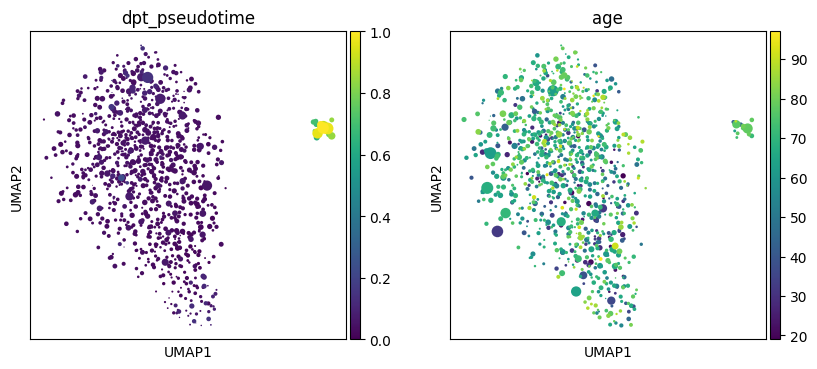

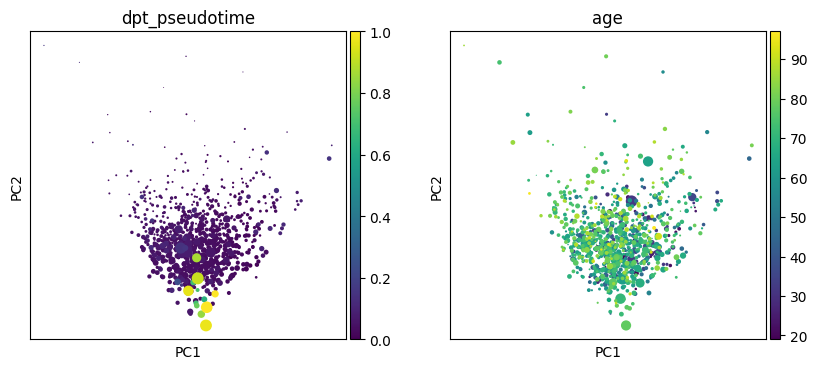

consistency of pseudotime with age: SignificanceResult(statistic=0.15879823667817183, pvalue=5.759292664506055e-07)


In [167]:
adata = adata_dict[data1]
adata.obs.index = adata.obs.index.astype(int)

run_pseudotime_analysis(adata, seed=32)
print(f"consistency of pseudotime with age: {spearmanr(adata.obs['dpt_pseudotime'], adata.obs['age'])}")

# Pseudotime analysis: TF activity 

In [168]:
tf_acts_adata1 = tf_acts_adata_dict[data1]
tf_acts_adata7 =  tf_acts_adata_dict[data2]

Using 23 (index 23) as the root for pseudotime.


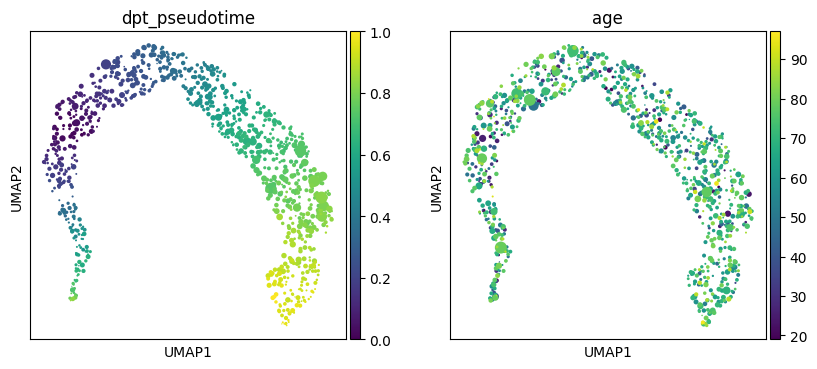

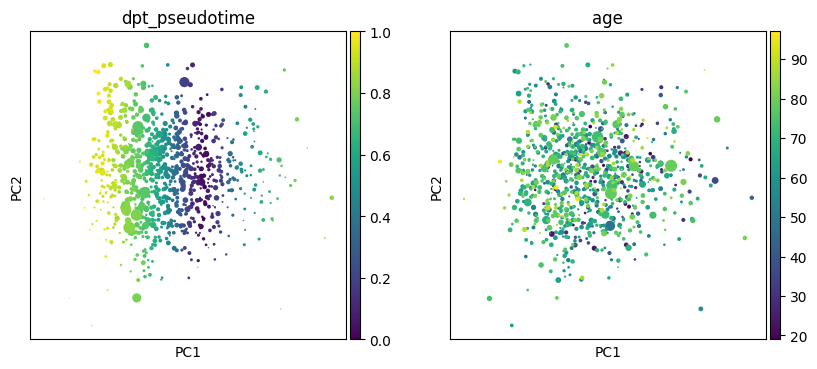

In [169]:
run_pseudotime_analysis(tf_acts_adata1, seed=32)

In [170]:
print(f"consistency of pseudotime with age: data1: {spearmanr(tf_acts_adata1.obs['dpt_pseudotime'], tf_acts_adata1.obs['age'])}")

consistency of pseudotime with age: data1: SignificanceResult(statistic=0.10513379886059587, pvalue=0.0009743436913671005)


Using 23 (index 23) as the root for pseudotime.


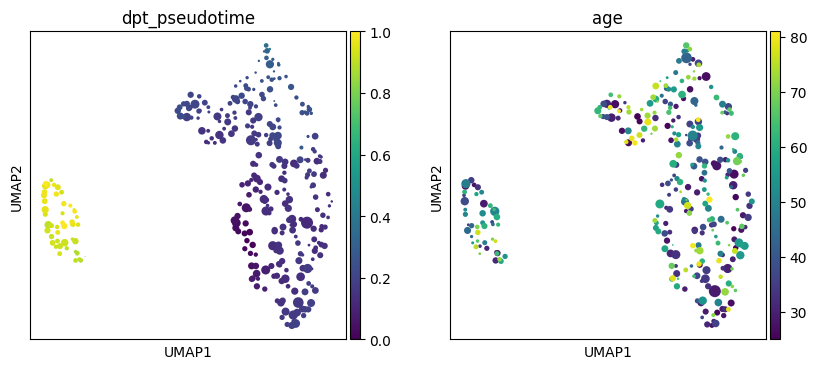

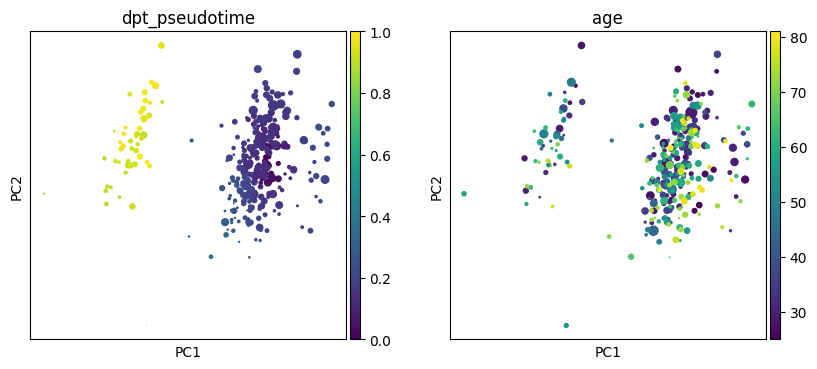

In [171]:
run_pseudotime_analysis(tf_acts_adata7, seed=32)

In [172]:
print(f"consistency of pseudotime with age: data7: {spearmanr(tf_acts_adata7.obs['dpt_pseudotime'], tf_acts_adata7.obs['age'])}")

consistency of pseudotime with age: data7: SignificanceResult(statistic=0.05683474771341687, pvalue=0.31620031551655353)


## Top TF predictor of pseudo age

In [173]:
# - remove those samples with invalid pseudotime (seems like it's only for MONO)
invalid_pseudotime_samples = tf_acts_adata7.obs['dpt_pseudotime']==np.inf
print(f"Removing {invalid_pseudotime_samples.sum()} samples with invalid pseudotime")
tf_acts_adata7 = tf_acts_adata7[~invalid_pseudotime_samples, :]

Removing 0 samples with invalid pseudotime


In [174]:
target = 'dpt_pseudotime'

top_predictors_dpt_data1 = find_robust_predictors(
    tf_acts_adata1, covariates, target, top_k=par['top_n_predictor_tf']
)
top_predictors_dpt_data7 = find_robust_predictors(
    tf_acts_adata7, covariates, target, top_k=par['top_n_predictor_tf']
)
predictor_tfs_dpt = (set(top_predictors_dpt_data1) & set(top_predictors_dpt_data7))
print('\n predictor_tfs_dpt: ',predictor_tfs_dpt)

Selected 50 most important features.
Final Model R²: 0.76, Spearman: 0.90
Most important predictors: ['FOSB', 'RORA', 'RNASEH2C', 'CHD2', 'SUCLG1', 'CSNK2B', 'UQCRB', 'SPAG7', 'CREM', 'RPS10', 'HCLS1', 'TRIM69', 'BAX', 'RAN', 'DRAP1', 'POU2F2', 'ARID3A', 'ZNF331', 'ZBTB38', 'NAP1L1', 'UBB', 'LYL1', 'SPI1', 'CANX', 'PKM', 'NCOA3', 'DDIT3', 'NME1', 'PRDX5', 'SPATS2', 'HSPA5', 'CYCS', 'GTF2A2', 'FOS', 'RPS4X', 'HHEX', 'CD59', 'NUCB1', 'CREB3', 'BHLHE41', 'FOXP1', 'PRDM1', 'P4HB', 'TFDP1', 'RPL6', 'MYBL2', 'SNRPB2', 'ATF4', 'EZH2', 'XBP1']
Selected 50 most important features.
Final Model R²: 0.98, Spearman: 0.80
Most important predictors: ['KLF4', 'NFKB1', 'JUN', 'SF3B1', 'RPS10', 'BACH2', 'UBB', 'NAP1L1', 'ZNF236', 'SOX5', 'KLF7', 'NR3C1', 'ETS1', 'ADNP', 'H1FX', 'ZNF296', 'PHF20', 'JUND', 'ZNF860', 'CUX1', 'RAN', 'EP300', 'NCOR1', 'ZNF800', 'UQCRB', 'SMAD3', 'ZNF407', 'YWHAZ', 'TCF7', 'KLF6', 'LCOR', 'NR4A2', 'EGR1', 'KDM2A', 'FOSB', 'SF1', 'NCOA1', 'NCOR2', 'SPIB', 'MAPK1', 'TRIM69', 'J

In [175]:
if len(predictor_tfs_dpt)==0:
    print("No common predictors found.")
    sig_predictor_tfs_dpt = None
else:
    stats_top_tf_predictors_dpt = determin_stats(tf_acts_adata_dict, predictor_tfs_dpt, par['datasets'])
    summary_stats_top_tf_predictors_dpt = summary_stats(stats_top_tf_predictors_dpt)
    print(summary_stats_top_tf_predictors_dpt.head(10))
    if False:
        plot_trends(summary_stats_top_tf_predictors_dpt['tf'].values, datasets, tf_acts_adata_dict, datasets_colors, cell_type, stats_df)

       tf  p_value_adj     slope  spearman_corr        r2
0    CYCS     0.134584 -0.002800      -0.043710  0.007071
1     RAN     0.221286       NaN            NaN  0.016534
2   RPS10     1.000000       NaN            NaN  0.000562
3    FOSB     0.064234       NaN            NaN  0.011133
4  TRIM69     1.000000       NaN            NaN  0.001266
5     UBB     1.000000       NaN            NaN  0.001289
6  NAP1L1     1.000000  0.000789       0.051568  0.006976
7   UQCRB     1.000000  0.001209       0.008731  0.000840


# Summarize results

In [176]:
summary_stats_top_tf_predictors_dpt['type'] = 'dpt'
summary_stats_top_tf_predictors['type'] = 'age'
summary_stats_central_tfs['type'] = 'centrality'

stats_all = pd.concat([summary_stats_top_tf_predictors, summary_stats_top_tf_predictors_dpt, summary_stats_central_tfs])


## Add sig stats obtained from expression values

In [177]:
sig_tfs_all = stats_all['tf'].unique()
stats_sig_tfs_all_expression = determin_stats(adata_dict, sig_tfs_all, par['datasets'])
summary_stats_sig_tfs_all_expression = summary_stats(stats_sig_tfs_all_expression)
print(summary_stats_sig_tfs_all_expression.head())
if False:
    plot_trends(summary_stats_sig_tfs_all_expression['tf'].values, datasets, adata_dict, datasets_colors, cell_type, stats_sig_tfs_all_expression)

      tf  p_value_adj     slope  spearman_corr        r2
0  NR4A2     0.411707       NaN            NaN  0.012150
1   CYCS     1.000000       NaN            NaN  0.000054
2   SPI1     1.000000       NaN            NaN  0.001366
3   SPIB     1.000000 -0.000665      -0.039963  0.002336
4   IRF8     1.000000 -0.000305      -0.022311  0.000196


In [178]:
if summary_stats_sig_tfs_all_expression.shape[0] > 0:
    stats_all = stats_all.merge(summary_stats_sig_tfs_all_expression, on='tf', suffixes=('', '_expression'), how='left')

In [179]:
import os 
os.makedirs(f'{output_dir}/tf_activation', exist_ok=True)
output_file = f'{output_dir}/tf_activation/{cell_type}.csv'

stats_all['cell_type'] = cell_type
stats_all.to_csv(output_file, index=False)

## Plot intersections

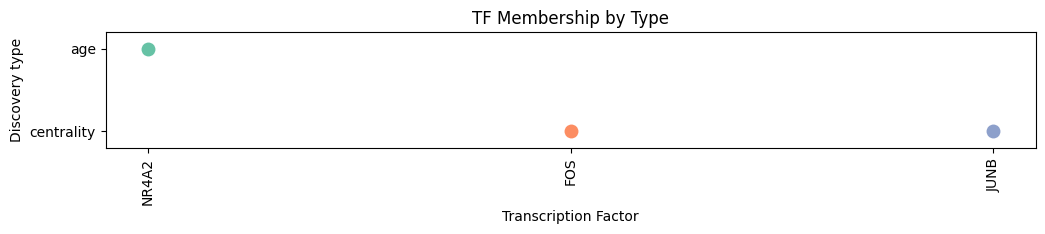

In [180]:
import seaborn as sns
import matplotlib.pyplot as plt

stats_all_sig = stats_all[stats_all['p_value_adj']<0.05]

plt.figure(figsize=(12, 1.5))
sns.stripplot(data=stats_all_sig, x="tf", y="type", jitter=True, palette="Set2", marker="o", size=10)
plt.xticks(rotation=90, ha="center")
plt.xlabel("Transcription Factor")
plt.ylabel("Discovery type")
plt.margins(x=0.05, y=0.2)
plt.title("TF Membership by Type")
plt.show()